In [1]:
import os


folder_path = r'D:\BitSom Python\Module 3\Part1\Part 4'

try:
    print("Files found in folder:", os.listdir(folder_path))
except Exception as e:
    print("Error:", e)


Files found in folder: ['part4_visualization_ml.ipynb', 'students.csv']


In [2]:
import pandas as pd
import os


folder_path = r'D:\BitSom Python\Module 3\Part1\Part 4' 
file_name = 'students.csv'
full_path = os.path.join(folder_path, file_name)

# Load the data
df = pd.read_csv(full_path)

# Display the data
print("Data loaded successfully!")
df


Data loaded successfully!


,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0
5,Frank,60,65,72,58,70,78,2.5,1
6,Grace,55,48,44,52,62,60,1.5,0
7,Henry,82,79,85,77,90,88,4.0,1
8,Iris,70,74,68,65,78,80,3.5,1
9,Jack,30,35,40,28,45,50,0.5,0


In [3]:
import pandas as pd


df = pd.read_csv(full_path)

print("--- 1. First 5 Rows ---")
print(df.head())

print("\n--- 2. Shape and Data Types ---")
print(f"Shape: {df.shape}")
print(df.dtypes)

print("\n--- 3. Summary Statistics ---")
print(df.describe())

print("\n--- 4. Count of Passed vs Failed ---")
# 1 = Pass, 0 = Fail
print(df['passed'].value_counts())

print("\n--- 5. Average Score per Subject (Pass vs Fail) ---")
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("Averages for Passing Students:")
print(df[df['passed'] == 1][subject_cols].mean())

print("\nAverages for Failing Students:")
print(df[df['passed'] == 0][subject_cols].mean())

print("\n--- 6. Student with Highest Overall Average ---")
# Calculate average across the 5 subject columns for each row
df['overall_avg'] = df[subject_cols].mean(axis=1)

# Find the row with the maximum average
top_student = df.loc[df['overall_avg'].idxmax()]

print(f"Top Student: {top_student['name']}")
print(f"Average Score: {top_student['overall_avg']:.2f}")


--- 1. First 5 Rows ---
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

--- 2. Shape and Data Types ---
Shape: (15, 9)
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

--- 3. Summary Statistics ---
   

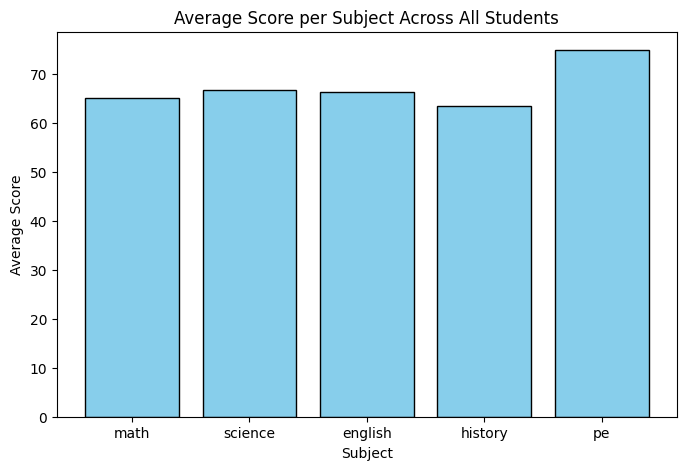

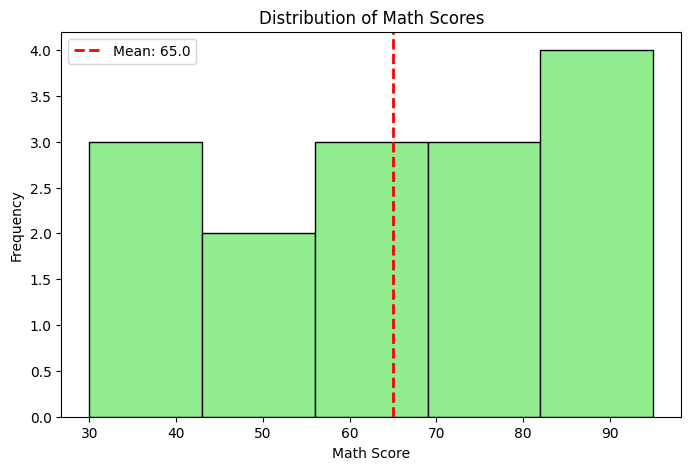

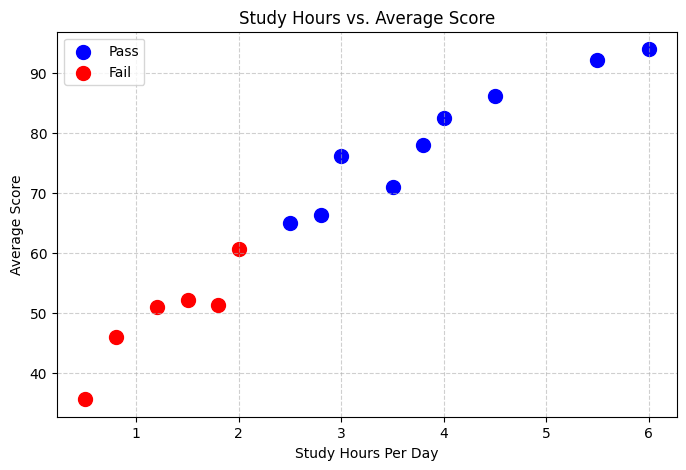

C:\Users\Admin\AppData\Local\Temp\ipykernel_3748\2111500964.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


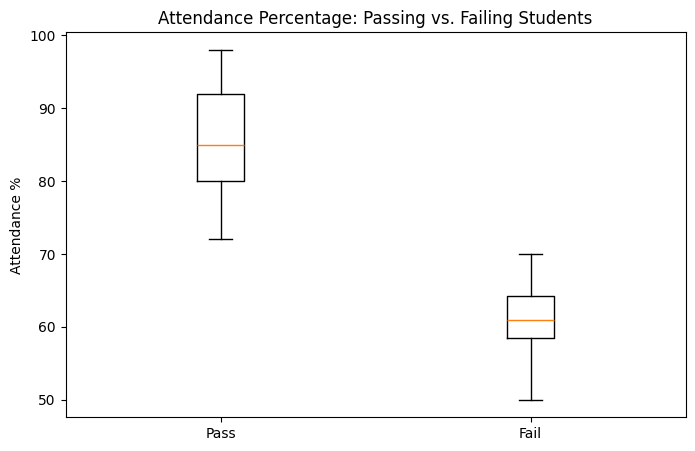

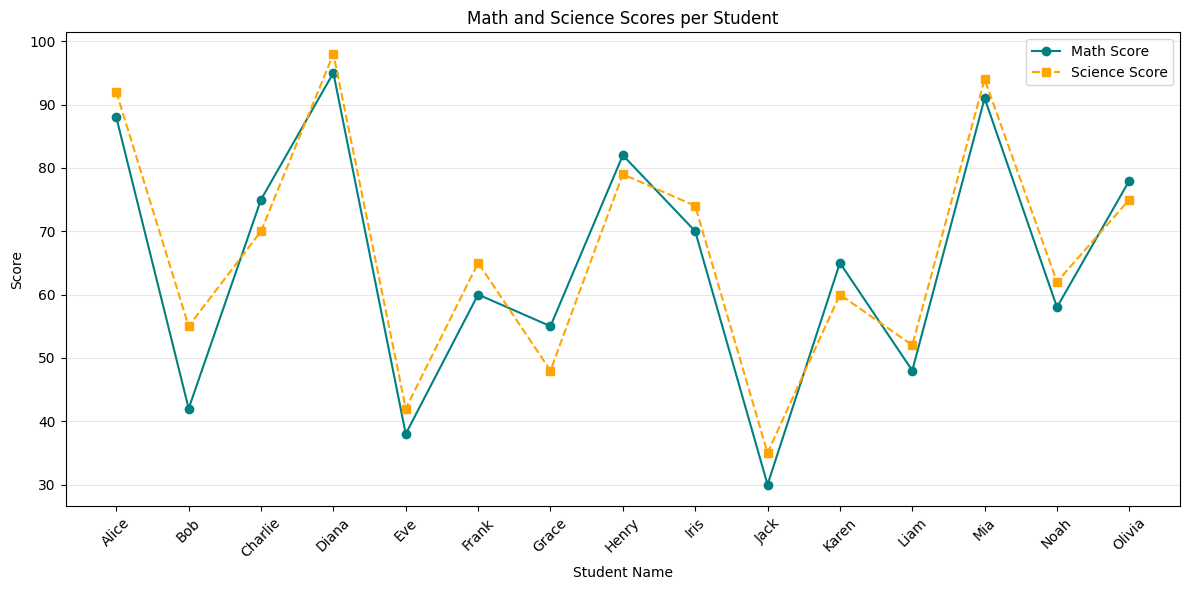

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Prerequisites: Define subject columns and calculate average score
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# --- 1. Bar Chart: Average Score Per Subject ---
plt.figure(figsize=(8, 5))
avg_per_subject = df[subject_cols].mean()
plt.bar(avg_per_subject.index, avg_per_subject.values, color='skyblue', edgecolor='black')
plt.title('Average Score per Subject Across All Students')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.savefig('plot1_bar.png')
plt.show()

# --- 2. Histogram: Distribution of Math Scores ---
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='lightgreen', edgecolor='black')
math_mean = df['math'].mean()
plt.axvline(math_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {math_mean:.1f}')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('plot2_histogram.png')
plt.show()

# --- 3. Scatter Plot: Study Hours vs. Average Score ---
plt.figure(figsize=(8, 5))
pass_group = df[df['passed'] == 1]
fail_group = df[df['passed'] == 0]

plt.scatter(pass_group['study_hours_per_day'], pass_group['avg_score'], color='blue', label='Pass', s=100)
plt.scatter(fail_group['study_hours_per_day'], fail_group['avg_score'], color='red', label='Fail', s=100)

plt.title('Study Hours vs. Average Score')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Average Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('plot3_scatter.png')
plt.show()

# --- 4. Box Plot: Attendance Percentage (Pass vs. Fail) ---
plt.figure(figsize=(8, 5))
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title('Attendance Percentage: Passing vs. Failing Students')
plt.ylabel('Attendance %')
plt.savefig('plot4_boxplot.png')
plt.show()

# --- 5. Line Plot: Math and Science Scores by Student ---
plt.figure(figsize=(12, 6))
plt.plot(df['name'], df['math'], marker='o', linestyle='-', label='Math Score', color='teal')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', label='Science Score', color='orange')

plt.title('Math and Science Scores per Student')
plt.xlabel('Student Name')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout() # Prevents label cutoff
plt.savefig('plot5_line.png')
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_3748\918545687.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='muted')
C:\Users\Admin\AppData\Local\Temp\ipykernel_3748\918545687.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='magma')


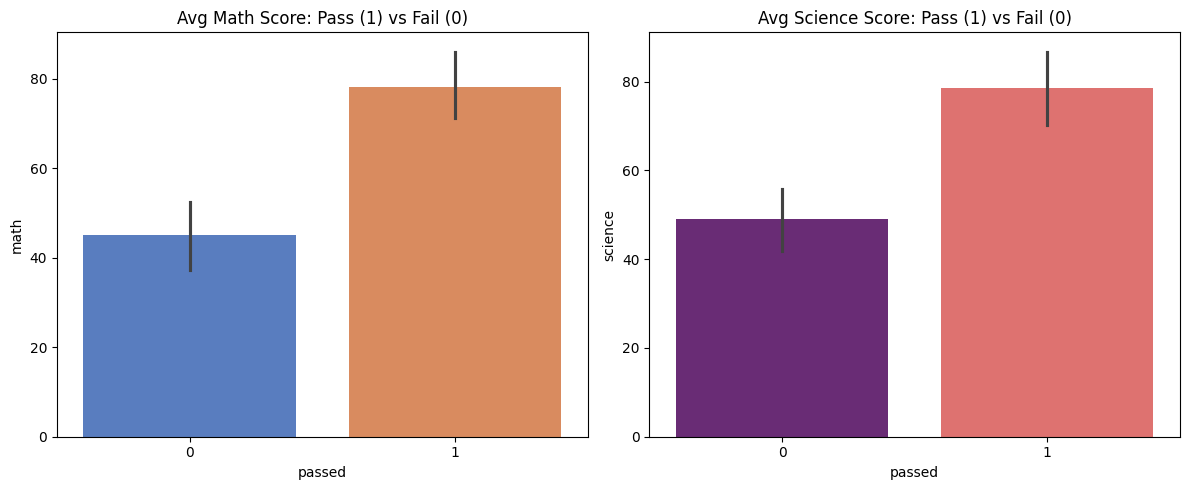

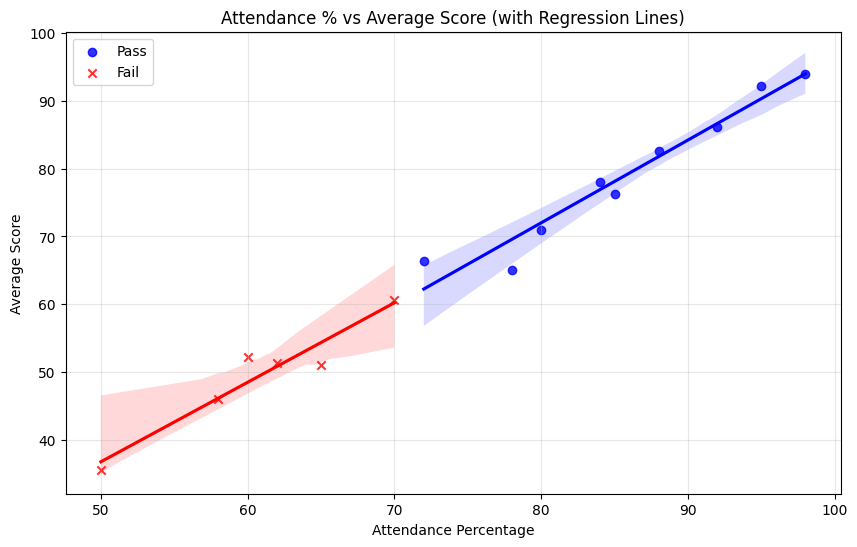

'\nComparison Comment:\nUsing Seaborn for the regression plot was much easier than Matplotlib because it calculates \nand draws the trend lines automatically in one step. While Matplotlib gives more manual \ncontrol over subplots, Seaborn produces more "polished" looking statistical charts \nwith significantly less code.\n'

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Bar Plot: Math and Science Scores split by Passed
# We use plt.subplots(1, 2) to create two side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='muted')
ax1.set_title('Avg Math Score: Pass (1) vs Fail (0)')

sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='magma')
ax2.set_title('Avg Science Score: Pass (1) vs Fail (0)')

plt.tight_layout()
plt.savefig('seaborn_bar_plots.png')
plt.show()

# 2. Scatter Plot with Regression Lines
plt.figure(figsize=(10, 6))

# Plotting the groups separately as requested in the hint
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', label='Pass', color='blue', marker='o')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', label='Fail', color='red', marker='x')

plt.title('Attendance % vs Average Score (with Regression Lines)')
plt.xlabel('Attendance Percentage')
plt.ylabel('Average Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('seaborn_scatter_reg.png')
plt.show()

'''
Comparison Comment:
Using Seaborn for the regression plot was much easier than Matplotlib because it calculates 
and draws the trend lines automatically in one step. While Matplotlib gives more manual 
control over subplots, Seaborn produces more "polished" looking statistical charts 
with significantly less code.
'''


Training Accuracy: 100.00%
Test Accuracy: 100.00%

Detailed Results:
Student: Jack     | Actual: 0 | Predicted: 0 | Correct
Student: Liam     | Actual: 0 | Predicted: 0 | Correct
Student: Alice    | Actual: 1 | Predicted: 1 | Correct

Feature Importance (Coefficients):
english             : 0.8125
attendance_pct      : 0.5219
study_hours_per_day : 0.4844
pe                  : 0.4750
math                : 0.4379
science             : 0.3230
history             : 0.2629


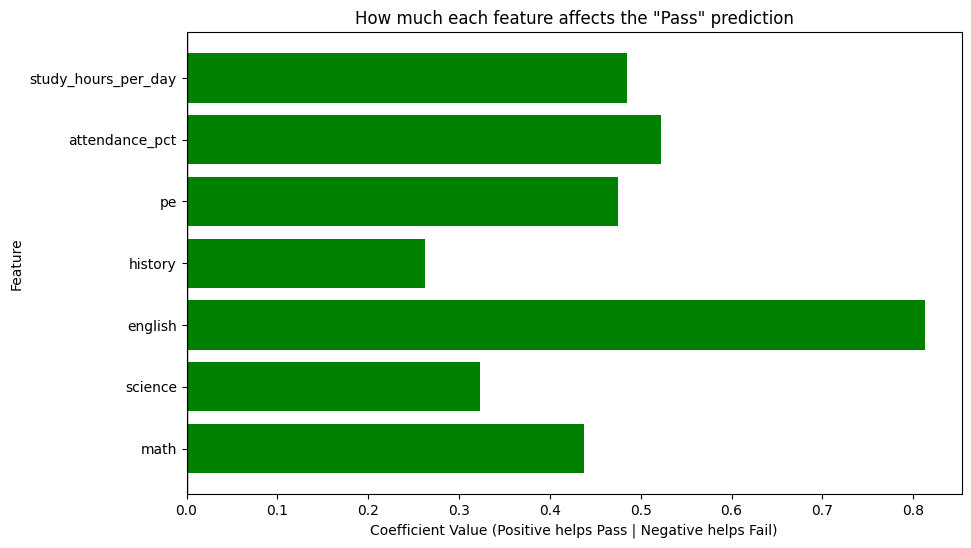

Prediction: Pass
Probability of Passing: 90.80%


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# --- Step 1: Prepare Data ---
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

# Split into 80% train and 20% test (random_state ensures same results every time)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (very important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Step 2: Train a Model ---
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print(f"Training Accuracy: {model.score(X_train_scaled, y_train):.2%}")

# --- Step 3: Evaluate the Model ---
y_pred = model.predict(X_test_scaled)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")

# Get student names from the original dataframe using the test index
test_names = df.loc[X_test.index, 'name']

print("Detailed Results:")
for name, actual, pred in zip(test_names, y_test, y_pred):
    result_status = "Correct" if actual == pred else "Incorrect"
    print(f"Student: {name:8} | Actual: {actual} | Predicted: {pred} | {result_status}")

# --- Step 4: Feature Importance ---
# model.coef_[0] gives the 'weight' of each subject
coefficients = model.coef_[0]
feature_importance = sorted(zip(feature_cols, coefficients), key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance (Coefficients):")
for feat, val in feature_importance:
    print(f"{feat:20}: {val:.4f}")

# Create Horizontal Bar Chart
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coefficients]
plt.barh(feature_cols, coefficients, color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('How much each feature affects the "Pass" prediction')
plt.xlabel('Coefficient Value (Positive helps Pass | Negative helps Fail)')
plt.ylabel('Feature')
plt.savefig('feature_importance.png')
plt.show()

# Use the same names we defined at the start
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']

# Turn the list into a tiny DataFrame so it has "names"
new_student_df = pd.DataFrame([[75, 70, 68, 65, 80, 82, 3.2]], columns=feature_cols)

# Now scale and predict (no more warning!)
new_student_scaled = scaler.transform(new_student_df)
prediction = model.predict(new_student_scaled)
probs = model.predict_proba(new_student_scaled)

print(f"Prediction: {'Pass' if prediction[0] == 1 else 'Fail'}")
print(f"Probability of Passing: {probs[0][1]:.2%}")
